18


/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_17908/456770718.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log10(np.abs(ksp_rad_disp[0,:,:])))


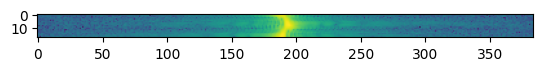

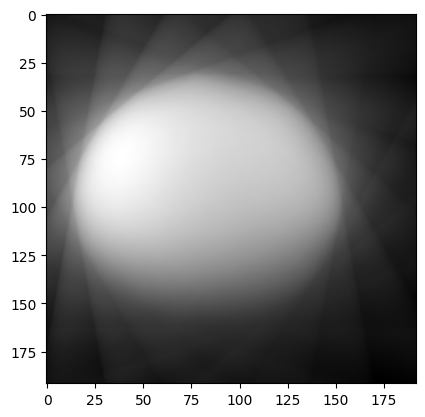

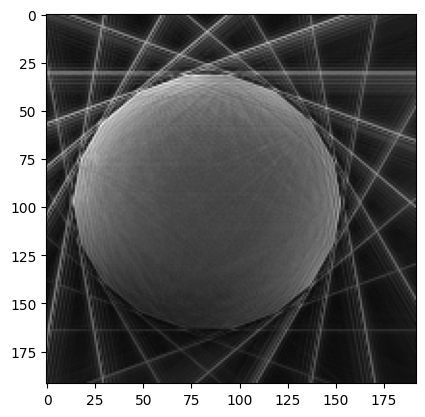

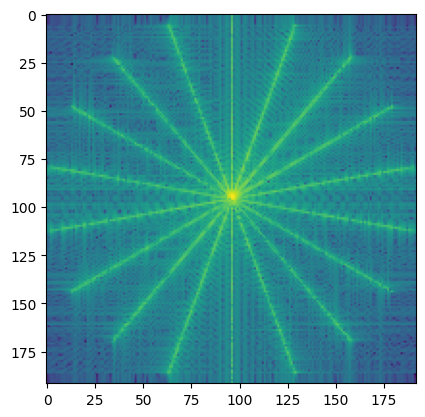

In [35]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
import os 
import torch 
import torchkbnufft as tkbn

fft = lambda inp, dim: np.fft.fftshift(np.fft.fft(np.fft.fftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
ifft = lambda inp, dim: np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
fft2 = lambda inp, dim=(0,1): fft(fft(inp,dim[0]),dim[1])
ifft2 = lambda inp, dim=(0,1): ifft(ifft(inp,dim[0]),dim[1])

datafile = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/fbirn_32ch_kspace.h5'

# !wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/fbirn_32ch_kspace.h5
# datafile = os.path.join(os.getcwd(), 'fbirn_32ch_kspace.h5')

with h5py.File(datafile,'r') as F:
    ksp = F['ksp'][:] # (192, 192, 32)

img = ifft2(ksp)
img = torch.tensor(img).permute(2,0,1)[None,...]


R = 16

nos = int(192*2) 
kr = torch.linspace(-np.pi, np.pi, nos)
nspokes = int(0.5*np.pi*192/R) 
print(nspokes)

ktraj = torch.zeros((2,nos*nspokes), dtype=kr.dtype)
for n in range(nspokes): 

    spoke_angle = n * 2 * np.pi / nspokes 
    i1 = n*nos 
    i2 = i1 + nos 
    ktraj[0,i1:i2] = kr * np.cos(spoke_angle)
    ktraj[1,i1:i2] = kr * np.sin(spoke_angle) 


ob_forward = tkbn.KbNufft(im_size=(192,192), numpoints=6)
ob_adjoint = tkbn.KbNufftAdjoint(im_size=(192,192), numpoints=6)

ksp_rad = ob_forward(img, ktraj) 

# display the radial k-space 
ksp_rad_disp = ksp_rad[0,:,:].reshape(32, nspokes, nos)
plt.figure()
plt.imshow(np.log10(np.abs(ksp_rad_disp[0,:,:])))
plt.show()

# reconstruct the image without density compensation 
img_no_dcomp = ob_adjoint(ksp_rad, ktraj)[0,...]
rss_no_dcomp = torch.sqrt(torch.sum(torch.abs(img_no_dcomp * img_no_dcomp.conj()), axis=0))
plt.figure()
plt.imshow(rss_no_dcomp.cpu(), cmap='gray')
plt.show()

# reconstruct the image without density compensation 
dcf = torch.abs(torch.linspace(-1, 1, nos))
dcf = torch.cat([dcf]*nspokes, dim=0)[None,None,:]
img_with_dcomp = ob_adjoint(ksp_rad * dcf, ktraj)[0,...]
rss_with_dcomp = torch.sqrt(torch.sum(torch.abs(img_with_dcomp * img_with_dcomp.conj()), axis=0))
plt.figure()
plt.imshow(rss_with_dcomp.cpu(), cmap='gray', vmin=0.0, vmax=torch.max(rss_with_dcomp))
plt.show()

# display the under-sampled "gridded" k-space for one coil 
ksp_with_dcomp = fft2(img_with_dcomp[0,...].cpu().numpy())
plt.figure()
plt.imshow(np.log10(np.abs(ksp_with_dcomp)))
plt.show()


# Point Spread Function (PSF)

Demonstrating "spreading out" of aliasing energy throughout the FOV

37


/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_17908/4159811130.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log10(np.abs(ksp_rad_disp[0,:,:])))


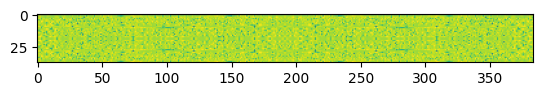

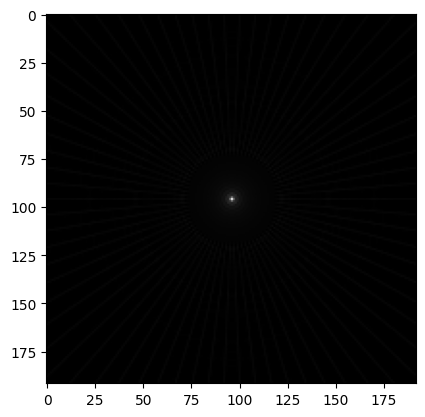

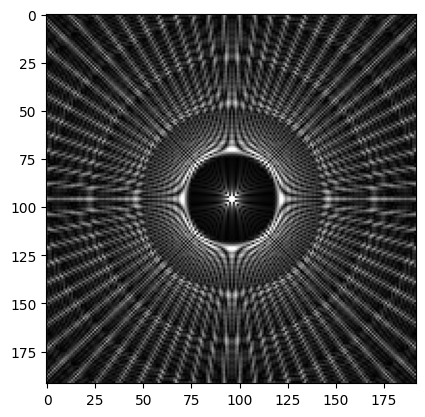

In [27]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
import os 
import torch 
import torchkbnufft as tkbn

fft = lambda inp, dim: np.fft.fftshift(np.fft.fft(np.fft.fftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
ifft = lambda inp, dim: np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
fft2 = lambda inp, dim=(0,1): fft(fft(inp,dim[0]),dim[1])
ifft2 = lambda inp, dim=(0,1): ifft(ifft(inp,dim[0]),dim[1])

datafile = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/fbirn_32ch_kspace.h5'

# !wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/fbirn_32ch_kspace.h5
# datafile = os.path.join(os.getcwd(), 'fbirn_32ch_kspace.h5')

with h5py.File(datafile,'r') as F:
    ksp = F['ksp'][:] # (192, 192, 32)

img = ifft2(ksp)
img = torch.tensor(img).permute(2,0,1)[None,...]

img = 0 * img 
img[0,:,96,96] = 1.0

R = 8

nos = int(192*2) 
kr = torch.linspace(-np.pi, np.pi, nos)
nspokes = int(0.5*np.pi*192/R) 
print(nspokes)

ktraj = torch.zeros((2,nos*nspokes), dtype=kr.dtype)
for n in range(nspokes): 

    spoke_angle = n * 2 * np.pi / nspokes 
    i1 = n*nos 
    i2 = i1 + nos 
    ktraj[0,i1:i2] = kr * np.cos(spoke_angle)
    ktraj[1,i1:i2] = kr * np.sin(spoke_angle) 


ob_forward = tkbn.KbNufft(im_size=(192,192))
ob_adjoint = tkbn.KbNufftAdjoint(im_size=(192,192))

ksp_rad = ob_forward(img, ktraj) 

# display the radial k-space 
ksp_rad_disp = ksp_rad[0,:,:].reshape(32, nspokes, nos)
plt.figure()
plt.imshow(np.log10(np.abs(ksp_rad_disp[0,:,:])))
plt.show()

# reconstruct the image without density compensation 
img_no_dcomp = ob_adjoint(ksp_rad, ktraj)[0,...]
rss_no_dcomp = torch.sqrt(torch.sum(torch.abs(img_no_dcomp * img_no_dcomp.conj()), axis=0))
plt.figure()
plt.imshow(rss_no_dcomp.cpu(), cmap='gray')
plt.show()

# reconstruct the image without density compensation 
dcf = torch.abs(torch.linspace(-1, 1, nos))
dcf = torch.cat([dcf]*nspokes, dim=0)[None,None,:]
img_with_dcomp = ob_adjoint(ksp_rad * dcf, ktraj)[0,...]
rss_with_dcomp = torch.sqrt(torch.sum(torch.abs(img_with_dcomp * img_with_dcomp.conj()), axis=0))
plt.figure()
plt.imshow(rss_with_dcomp.cpu(), cmap='gray', vmin=0.0, vmax=0.05*torch.max(rss_with_dcomp))
plt.show()


torch.Size([32, 128, 384])


/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_17908/3343826464.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log10(np.abs(ksp_rad_disp[0,:,:])))


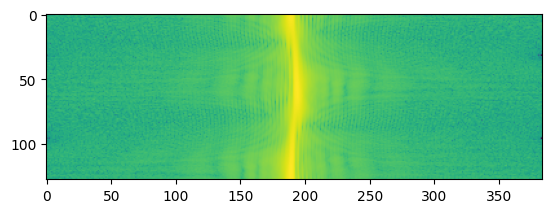

In [8]:
print(ksp_rad_disp.shape)
plt.figure()
plt.imshow(np.log10(np.abs(ksp_rad_disp[0,:,:])))
plt.show()